# Dark photon lifetime — acceptance-corrected cτ

`lifetime_validation.ipynb` shows the histogram-mean cτ is unbiased only while the
proper-decay-length distribution is faithful. At long lifetimes the generator caps the
*lab-frame* decay length at a fixed radius `R_max` (~8 m): a dark photon that would decay
beyond `R_max` in the lab is dropped, which removes the high-x tail of the *proper*
distribution and biases the mean (and eventually the core-slope fit) low.

### The truncation model

A decay with proper length `x` and boost `βγ` travels `ℓlab = βγ·x` in the lab. It
survives the cap iff `βγ·x < R_max`, i.e. iff `βγ < R_max/x`. The fraction of decays at
proper length `x` that survive is therefore the acceptance

  `ε(x) = P(βγ < R_max/x) = Fβγ(R_max/x)`,

where `Fβγ` is the CDF of the boost distribution. The *observed* proper density is the
intrinsic exponential times this acceptance:

  `dN/dx ∝ exp(−x/cτ) · Fβγ(R_max/x)`.

### Assumptions

1. **Sharp lab cap** — the generator drops decays beyond a single fixed `R_max`
   (validated below: the fitted `R_max` is consistent across the whole grid).
2. **Boost ⊥ lifetime** — `βγ` is set by the production kinematics (the masses), not by
   cτ, so `Fβγ` for a mass point is measured once from its shortest-cτ (faithful) sample
   and reused for all its lifetimes.
3. **Pure exponential intrinsic decay**, as generated.

Fitting `log(dN/dx) = logA − x/cτ + log Fβγ(R_max/x)` returns both the intrinsic cτ and
the lab cap `R_max`, with their covariance.

In [1]:
import sys, os, importlib
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# put the repo root on sys.path so `from sidm...` resolves to the working tree
sidm_path = os.getcwd().split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)
from sidm.tools import utilities
import lifetime_analysis as la
importlib.reload(la)

utilities.set_plot_style(dpi=110)   # mplhep CMS style + crisp inline figures

In [2]:
output = la.load_grid()                       # full-grid coffea (local cache or EOS)
rows, groups, bg_mean = la.compute_grid(output)
bgs = [bg_mean[k] for k in bg_mean]
print(f"{len(groups)} mass points, {len(rows)} samples; "
      f"<betagamma> in [{min(bgs):.0f}, {max(bgs):.0f}]")

36 mass points, 179 samples; <betagamma> in [16, 2735]


## Every fit, batched by mass point

As in the validation notebook, one panel per mass point with the cτ scan overlaid — but
here the curve is the **acceptance-corrected fit** `exp(−x/cτ)·Fβγ(R_max/x)` and the band
is its ±1σ uncertainty (from the full fit covariance). The fit follows the data through
the turn-over where the lab cap bites, and the legend reports the recovered cτ ± error.

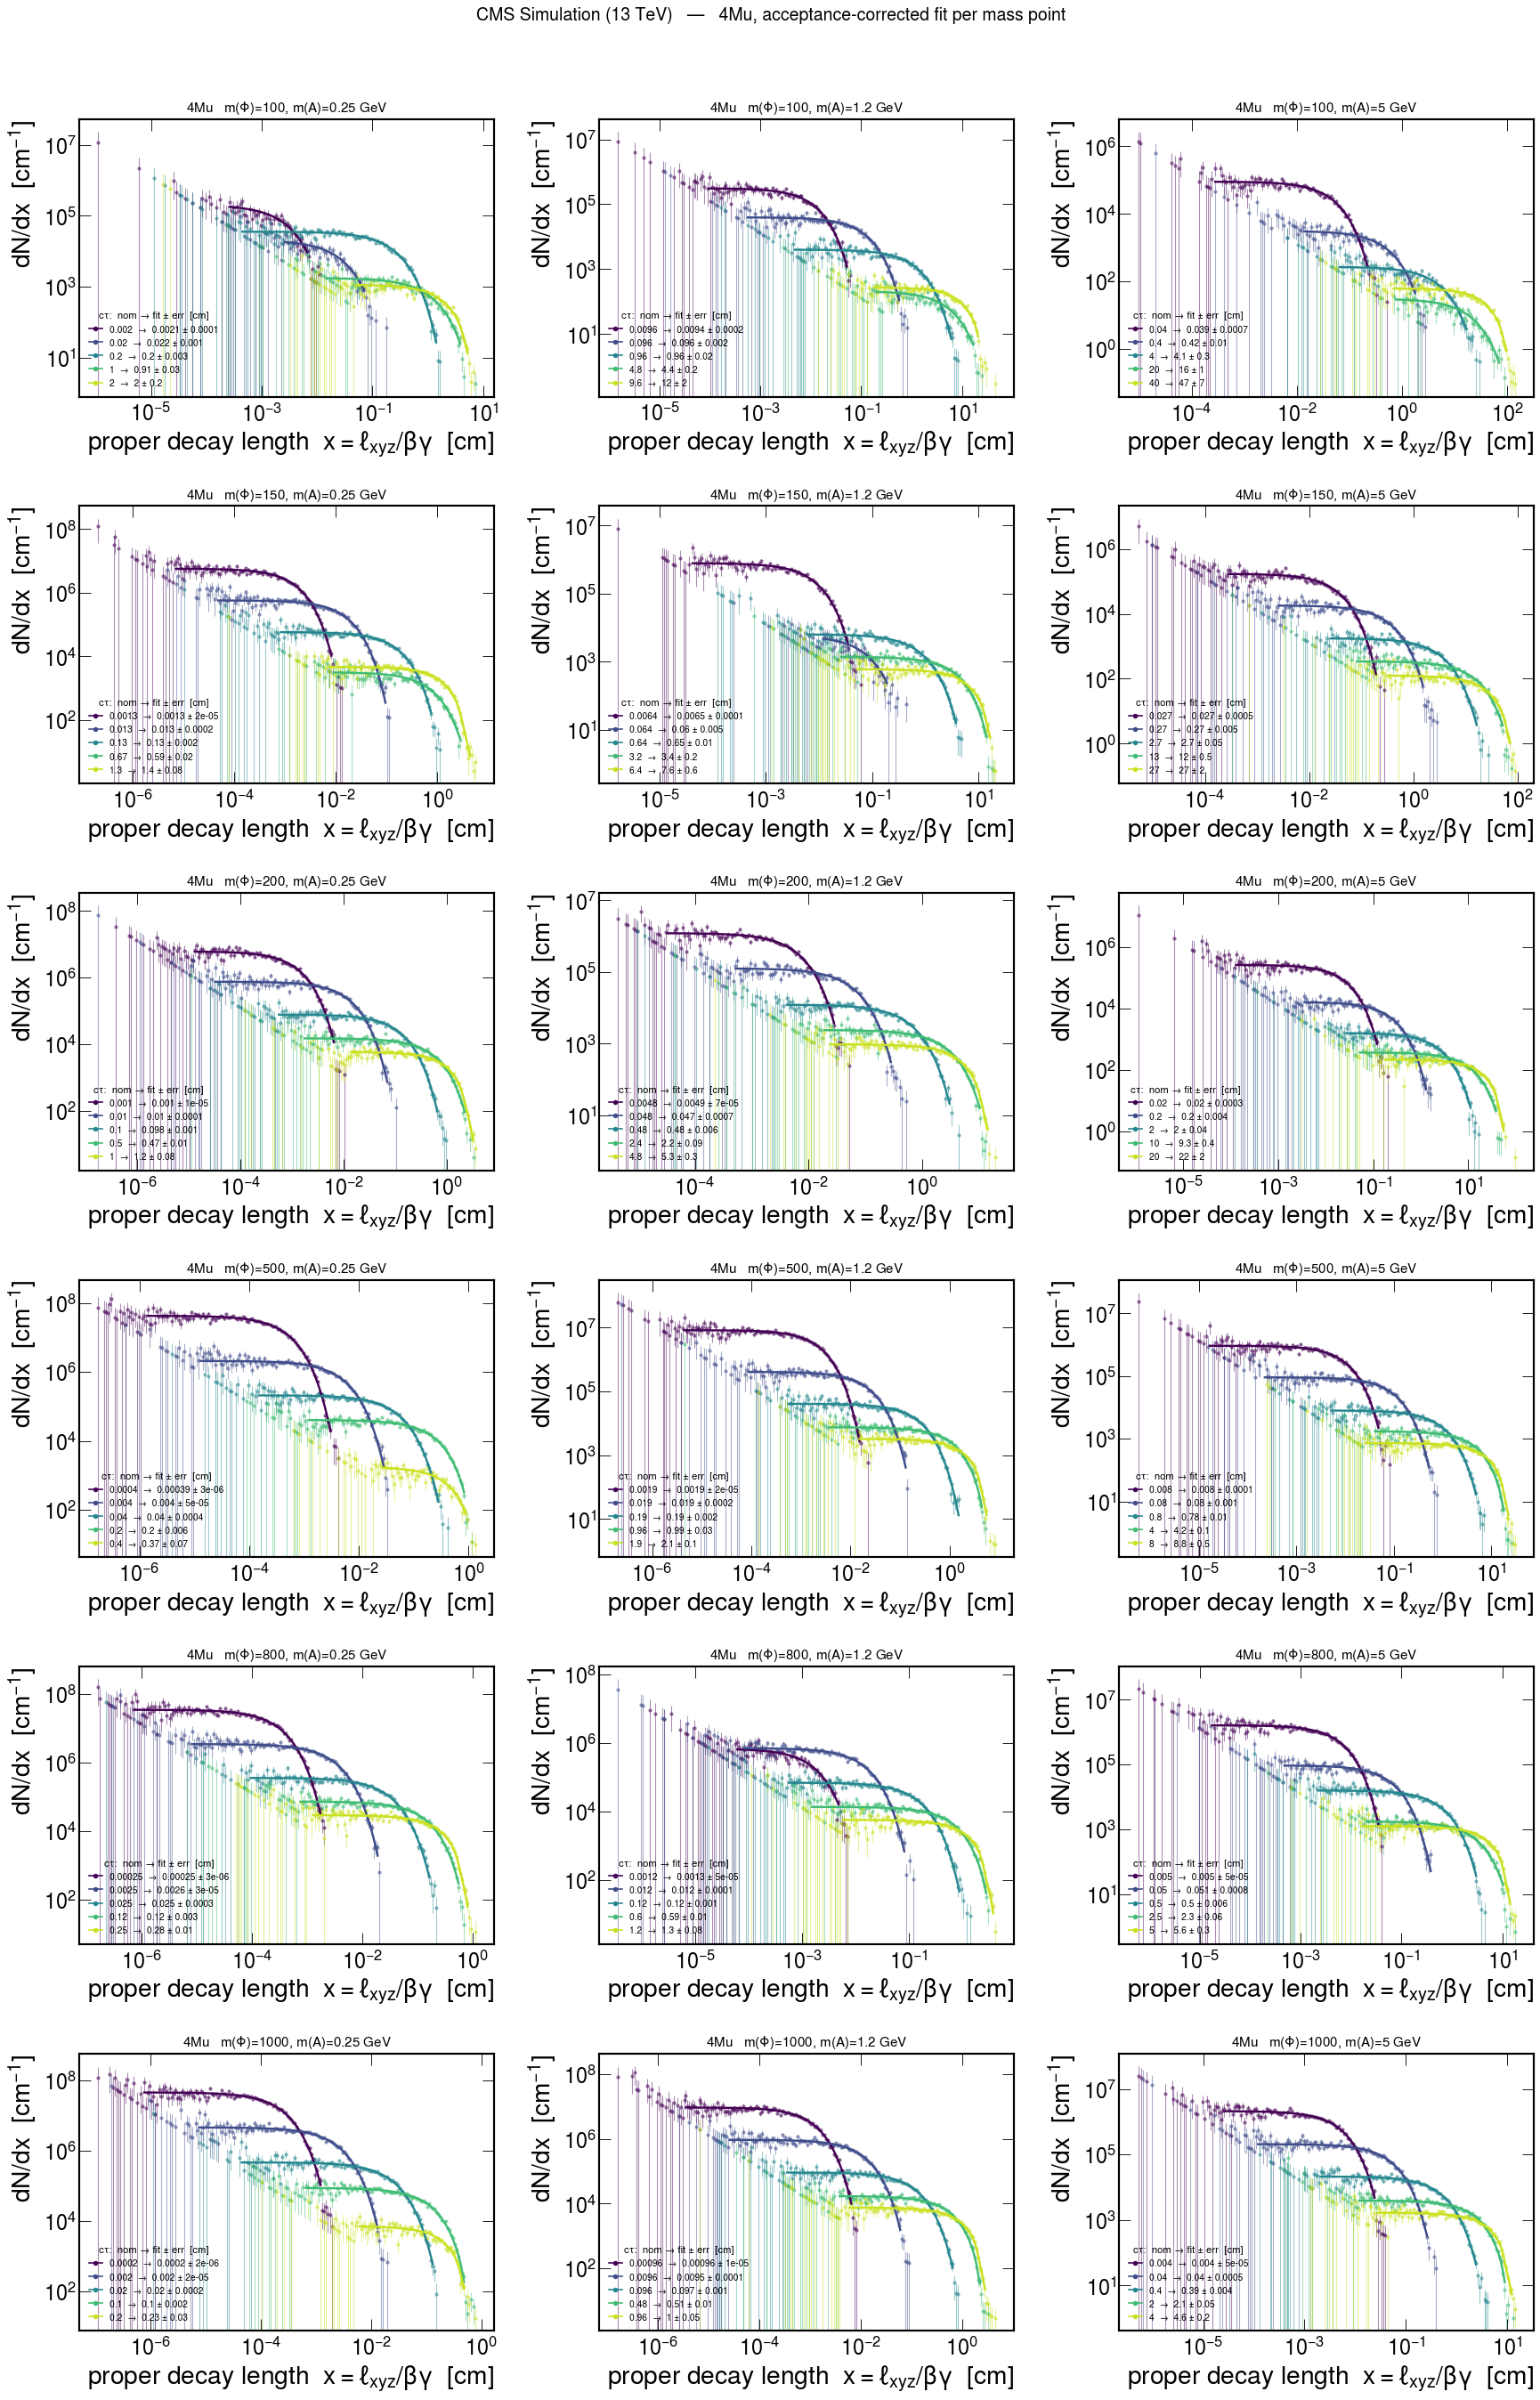

In [3]:
fig = la.plot_fit_grid(output, groups, "4Mu", kind="acceptance")

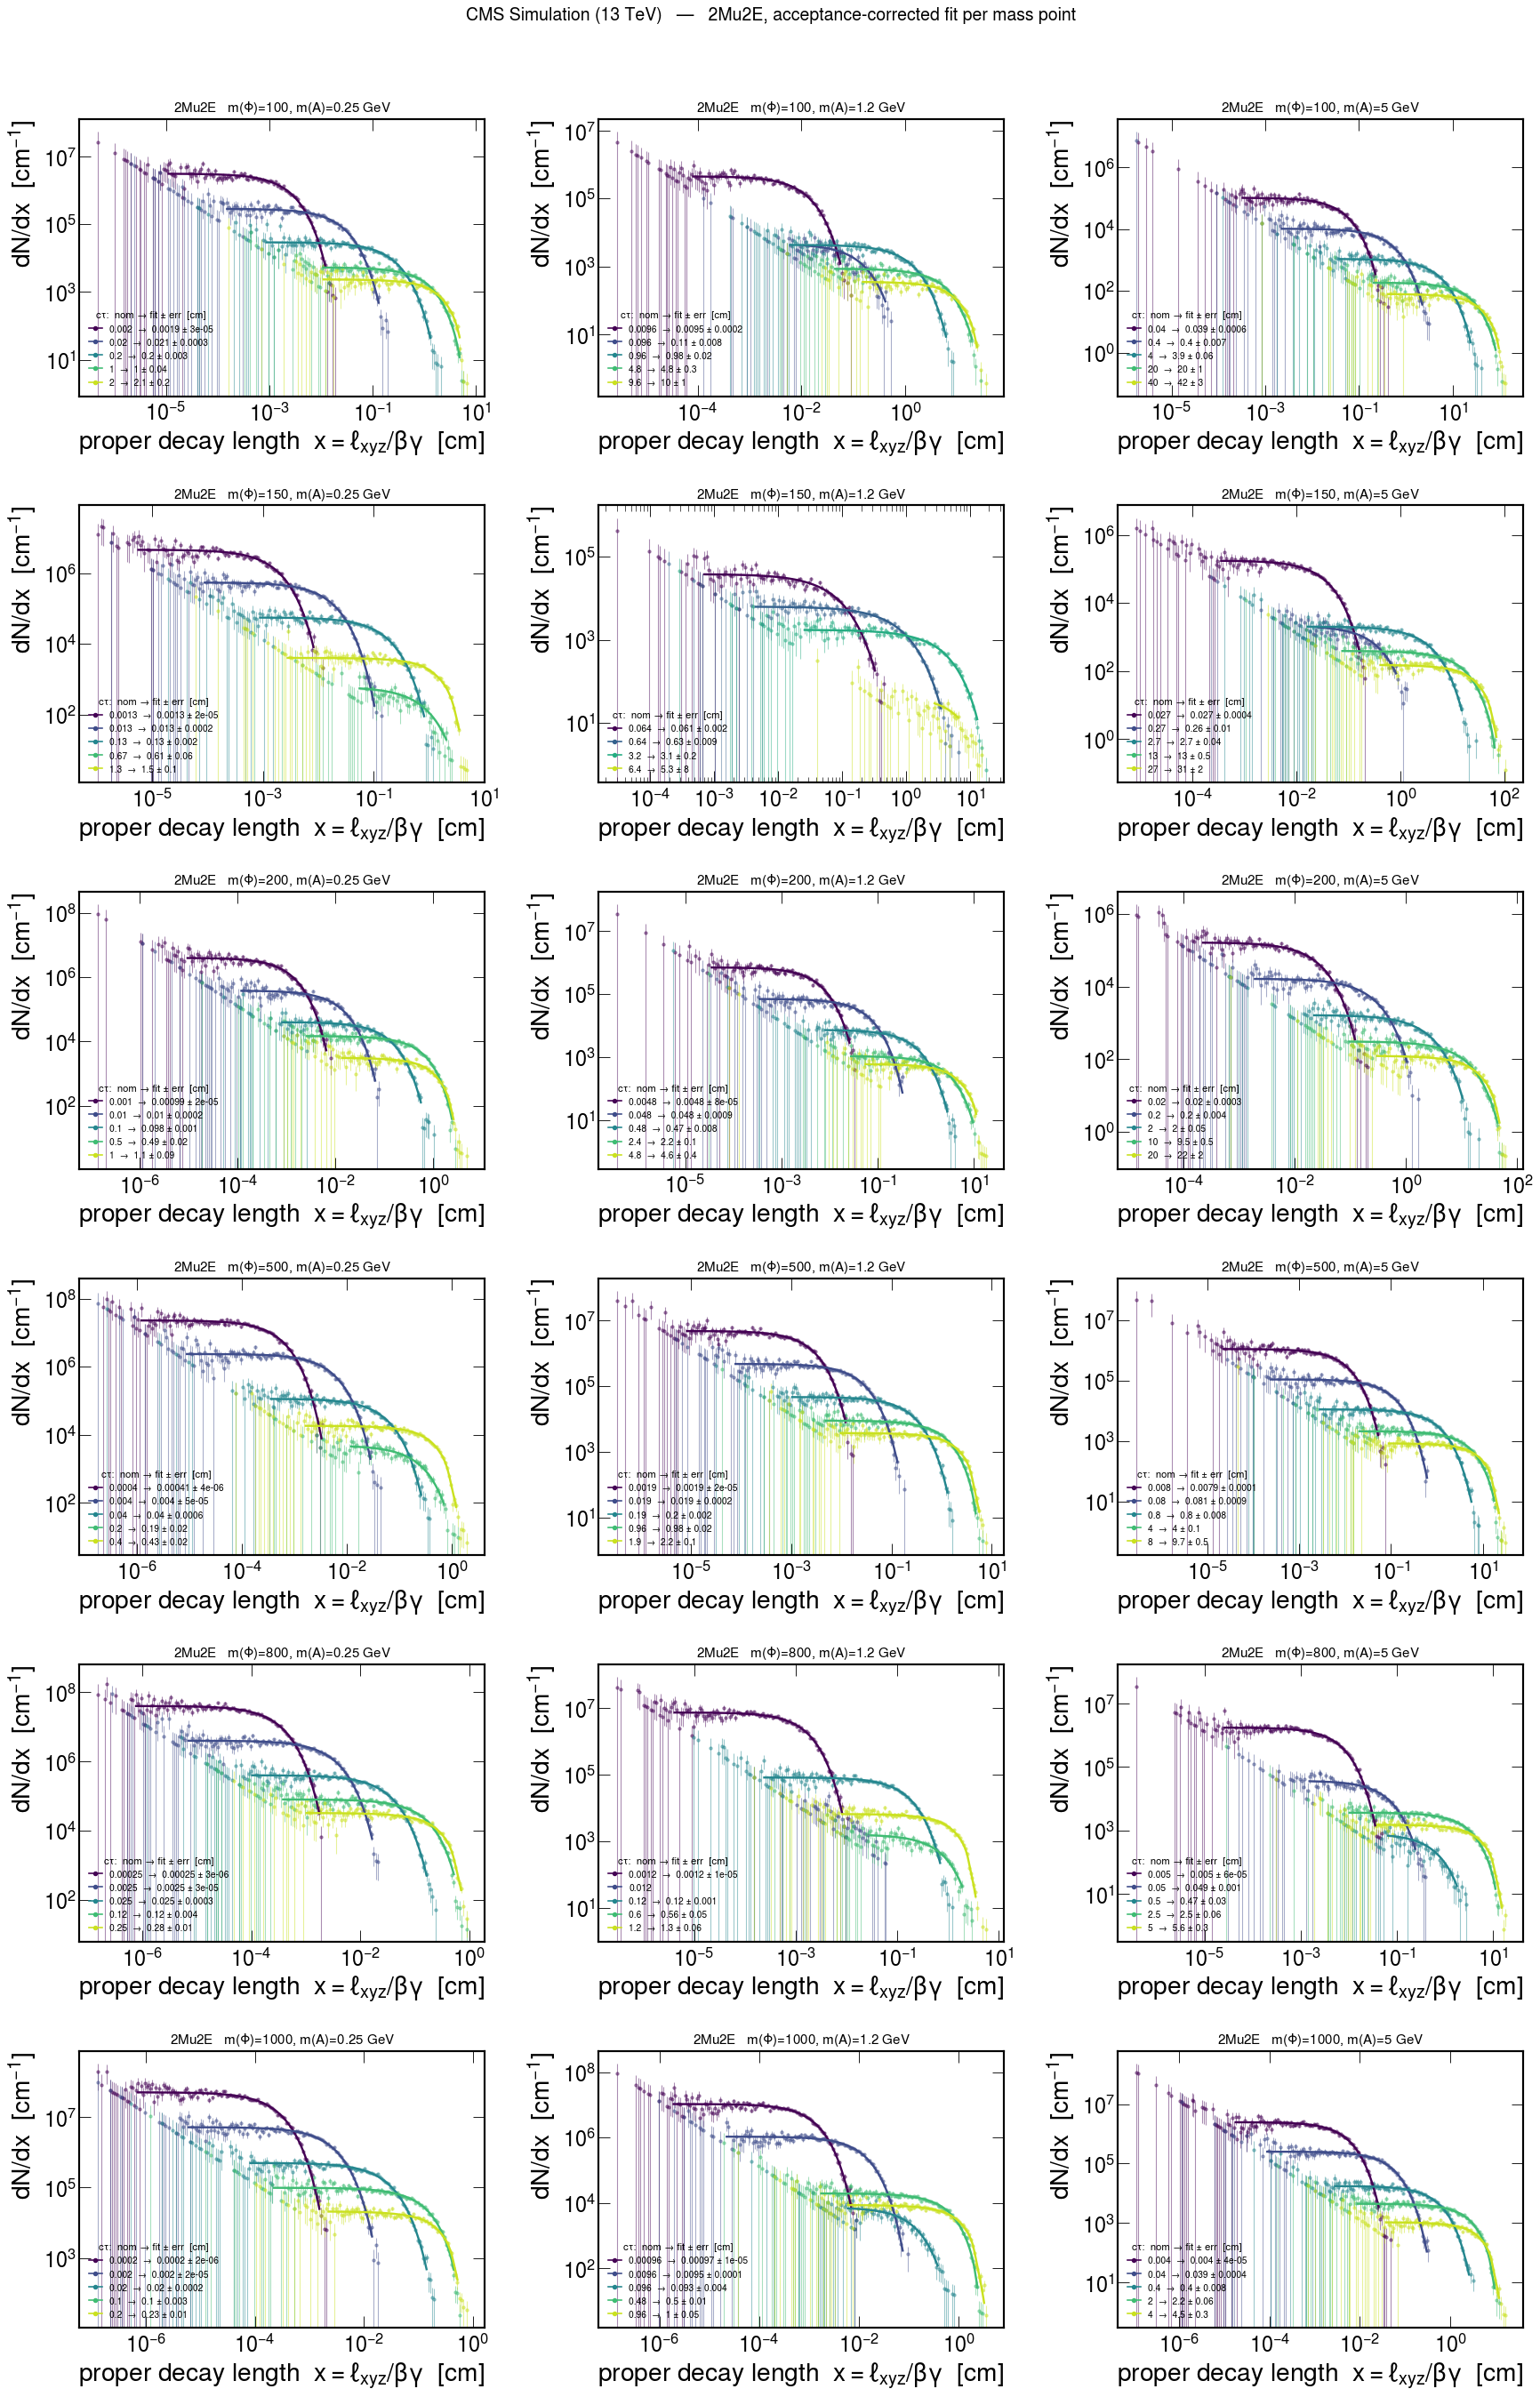

In [4]:
fig = la.plot_fit_grid(output, groups, "2Mu2E", kind="acceptance")

## Recovery across the full grid

The histogram mean (×) falls below 1 once the lab cap truncates the tail; the
acceptance-corrected fit (●, with its ±1σ error bar) folds the cap back in and recovers
`measured / nominal ≈ 1` across the whole grid.

acceptance-corrected, full grid: median measured/nominal = 1.001 (N=178)


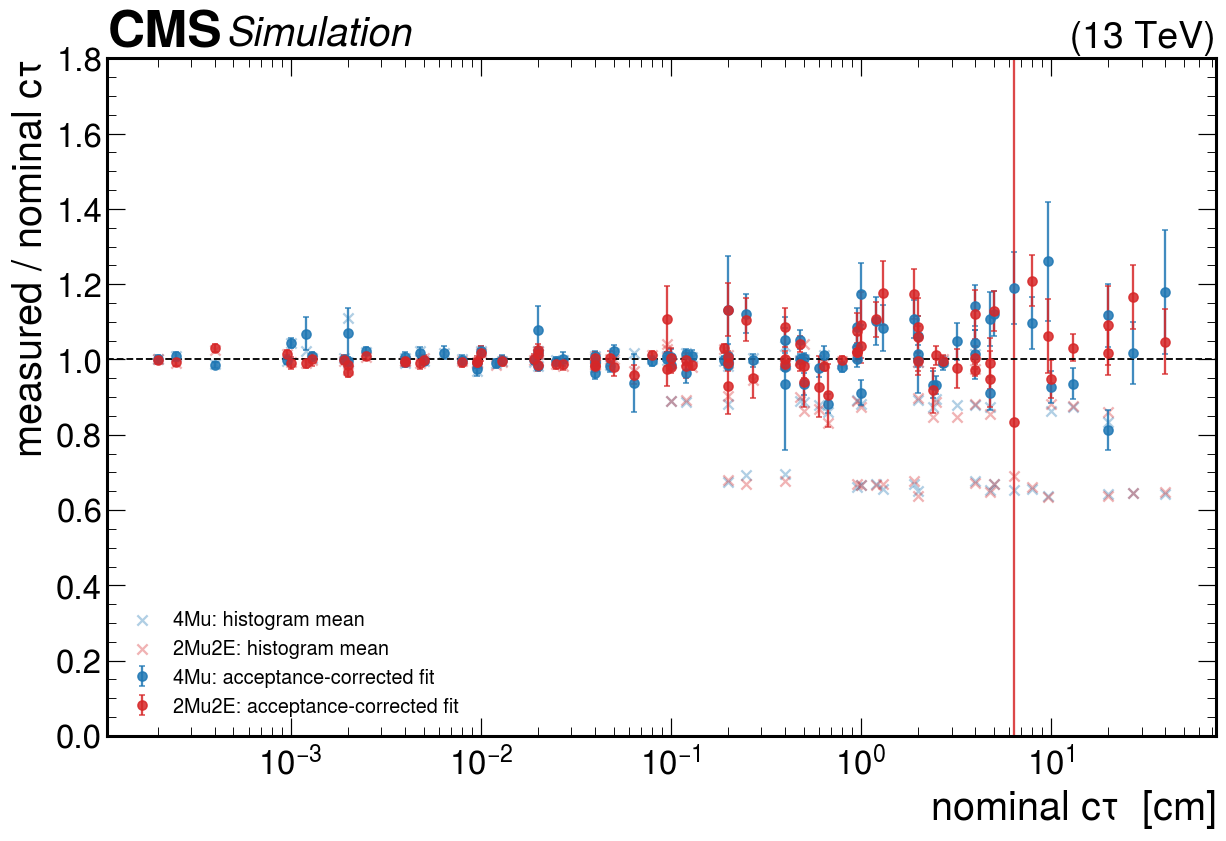

In [5]:
fig, ax = plt.subplots(figsize=(13, 8))
colors = {"4Mu": "#1f77b4", "2Mu2E": "#d62728"}
for ch, c in colors.items():
    rs = [r for r in rows.values() if r["mass_point"][0] == ch]
    nom = np.array([r["nominal"] for r in rs])
    mean = np.array([r["mean"] for r in rs])
    acc_ = np.array([r["acceptance"] for r in rs])
    acce = np.array([r["acceptance_err"] for r in rs])
    ax.scatter(nom, mean / nom, marker="x", s=45, color=c, alpha=0.35,
               label=f"{ch}: histogram mean")
    ax.errorbar(nom, acc_ / nom, yerr=acce / nom, fmt="o", ms=6, color=c, alpha=0.85,
                capsize=2, label=f"{ch}: acceptance-corrected fit")
ax.axhline(1.0, color="k", ls="--", lw=1.2)
ax.set_xscale("log")
ax.set_ylim(0, 1.8)
ax.set_xlabel(r"nominal $c\tau$  [cm]")
ax.set_ylabel(r"measured / nominal $c\tau$")
ax.legend(fontsize=13, loc="lower left", framealpha=0.9)
hep.cms.label(ax=ax, data=False)

corr = [r["acceptance"] / r["nominal"] for r in rows.values()
        if np.isfinite(r["acceptance"])]
print(f"acceptance-corrected, full grid: median measured/nominal "
      f"= {np.median(corr):.3f} (N={len(corr)})")

## The fitted lab cap is one number across the grid

Two cross-checks of assumption 1. **Left:** for heavily-truncated samples (where the cap
constrains the fit), the fitted `R_max` clusters on a single value with its ±1σ error.
**Right:** the cτ at which truncation sets in scales as `R_max / ⟨βγ⟩` — the onset cτ for
each mass point (where the mean crosses 0.9) runs parallel to the `R_max/βγ` reference over
two decades of boost, a fixed fraction below it (truncation begins before the typical lab
decay length reaches `R_max`).

median fitted R_max = 799 cm over 36 heavily-truncated samples


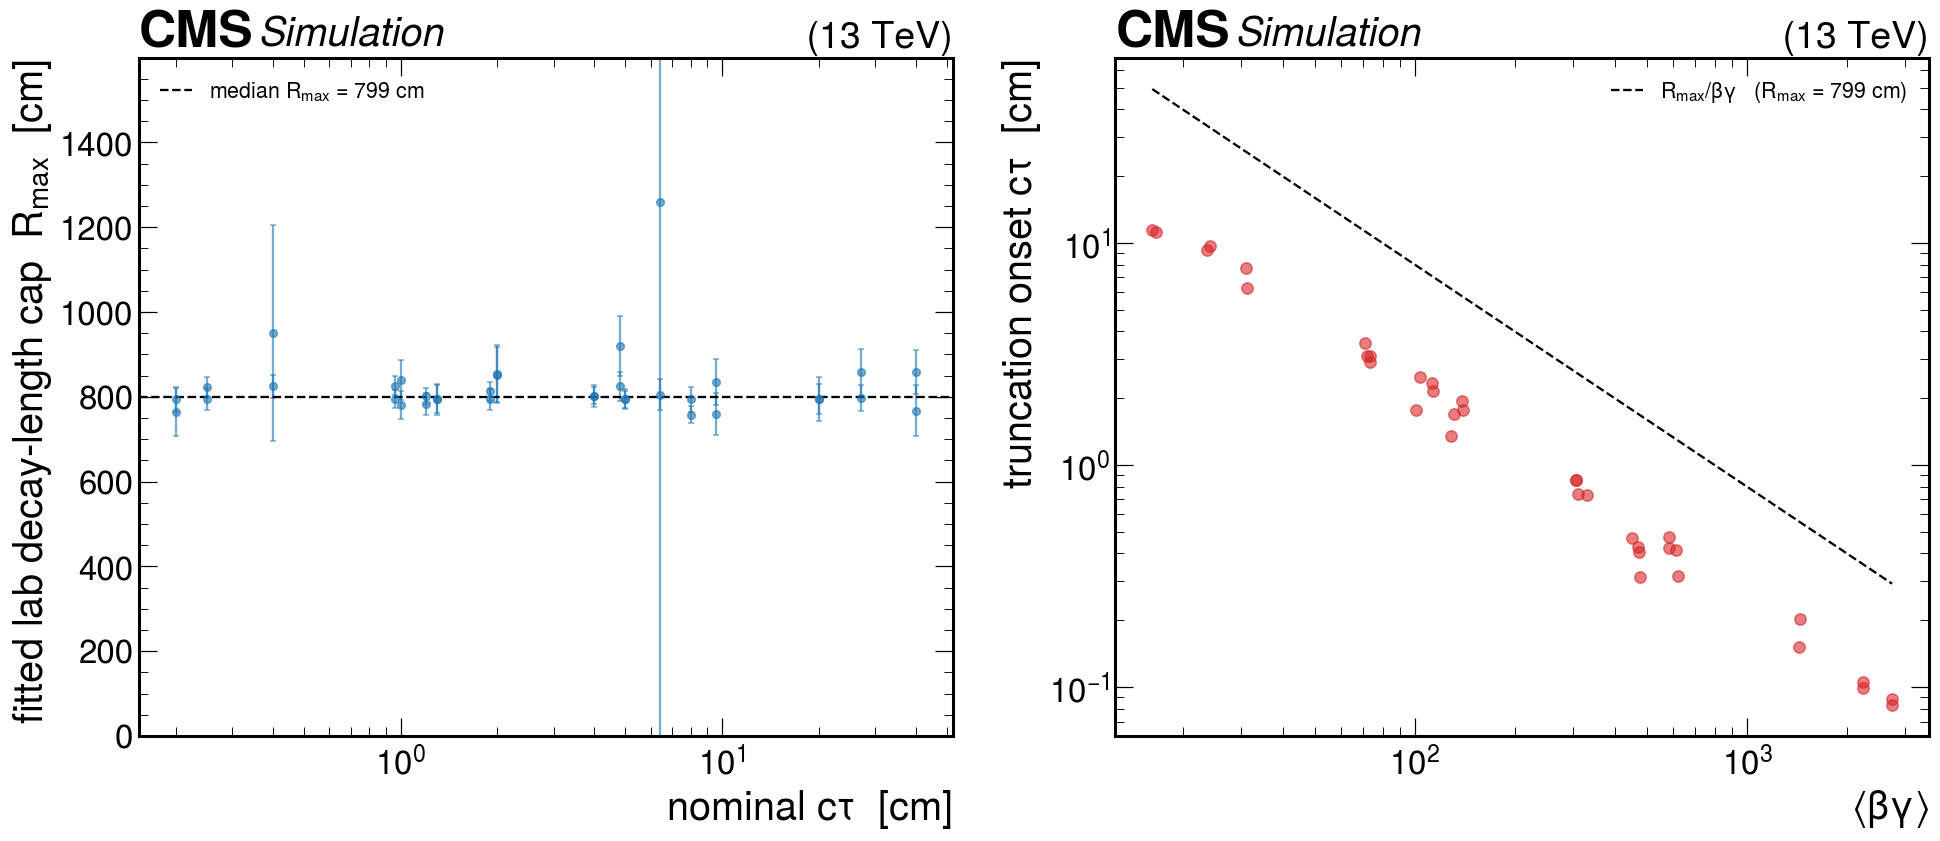

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(21, 8))

# left: fitted R_max for heavily-truncated samples
trunc = [r for r in rows.values()
         if np.isfinite(r["Rmax"]) and np.isfinite(r["Rmax_err"])
         and r["mean"] / r["nominal"] < 0.7]
nomt = np.array([r["nominal"] for r in trunc])
Rm = np.array([r["Rmax"] for r in trunc])
Rme = np.array([r["Rmax_err"] for r in trunc])
med = np.median(Rm)
axL.errorbar(nomt, Rm, yerr=Rme, fmt="o", ms=5, color="#1f77b4", alpha=0.6, capsize=2)
axL.axhline(med, color="k", ls="--", lw=1.5, label=rf"median $R_\mathrm{{max}}$ = {med:.0f} cm")
axL.set_xscale("log")
axL.set_ylim(0, 2 * med)
axL.set_xlabel(r"nominal $c\tau$  [cm]")
axL.set_ylabel(r"fitted lab decay-length cap  $R_\mathrm{max}$  [cm]")
axL.legend(fontsize=14)
hep.cms.label(ax=axL, data=False)

# right: truncation onset ctau vs <betagamma>
onset = []
for key, samples in groups.items():
    nn = np.array([la.ctau_cm(s) for s in samples])
    rr = np.array([rows[s]["mean"] / rows[s]["nominal"] for s in samples])
    below = np.where(rr < 0.9)[0]
    if len(below) and below[0] > 0:
        i = below[0]
        x0, x1 = np.log(nn[i - 1]), np.log(nn[i])
        y0, y1 = rr[i - 1], rr[i]
        onset.append((bg_mean[key], np.exp(x0 + (0.9 - y0) * (x1 - x0) / (y1 - y0))))
onset = np.array(onset)
axR.scatter(onset[:, 0], onset[:, 1], s=55, color="#d62728", alpha=0.6)
bgg = np.geomspace(onset[:, 0].min(), onset[:, 0].max(), 50)
axR.plot(bgg, med / bgg, "k--", lw=1.5, label=rf"$R_\mathrm{{max}}/\beta\gamma$   ($R_\mathrm{{max}}$ = {med:.0f} cm)")
axR.set_xscale("log")
axR.set_yscale("log")
axR.set_xlabel(r"$\langle\beta\gamma\rangle$")
axR.set_ylabel(r"truncation onset $c\tau$  [cm]")
axR.legend(fontsize=14)
hep.cms.label(ax=axR, data=False)

print(f"median fitted R_max = {med:.0f} cm over {len(trunc)} heavily-truncated samples")

## Result

A single lab decay-length cap (`R_max ≈ 8 m`), consistent across all mass points and both
channels, explains the truncation. Folding it back in as the acceptance `ε(x) =
Fβγ(R_max/x)` recovers the intrinsic proper cτ across the full grid, including the
long-lifetime samples where the histogram mean and core-slope fit break down.